# Inciso 4

### Importación de librerías.

In [16]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from networkx.algorithms import bipartite

### Importación de datos.

In [17]:
comments = pd.read_csv('youtube_comments.csv')
videos = pd.read_csv('youtube_videos.csv')

In [18]:
comments.head(2)

,video_id,comment_id,video_title,channel_name,channel_id,author_name,author_channel_id,text,source_query,source_group,dataset_sources,author_handle,published_text,like_count_text,reply_count,is_pinned,viewer_rating
0,j43HgwYFKfk,Ugw-J65a1iYL9hqhELh4AaABAg,La cooptación de Walter Mazariegos en la USAC,Quorum,UCE4rsXcgDb6e1-a9iTbWzfg,@MarcosCarillo-b1r,UCdFlugHJJa4l3YqWuNRmvXw,Ese corrupto amigo de la vieja fiscal los teng...,@quorumgt,topic,j43HgwYFKfk_out_comments.csv | quorum_complete...,/@MarcosCarillo-b1r,hace 6 meses,,0,False,NaN
1,06mFNPU0aB8,Ugw-ZT9t9wU2V-tCaUZ4AaABAg,Capturan a presuntos delincuentes disfrazados ...,Noti7,UCVpSRoZgngfSL03Nlbjtq9A,@RaulPerez-cw2vi,UCvl1tzQeBeGy6efPTRJXSCw,"Están jóvenes porque no buscan un trabajo, tu...",guatemala noticias,topic,youtube_guatemala_comments.csv | youtube_guate...,/@RaulPerez-cw2vi,hace 2 semanas,,0,False,NaN


In [19]:
videos.head(2)

,video_id,title,channel_name,channel_id,source_query,source_group,dataset_sources,channel_handle,published_time,view_count_text,description_snippet,video_url,query_hits,keywords,description,view_count,publish_date,upload_date,category,owner_handle
0,-5puKGEqcUc,INSIVUMEH pronostica incremento de lluvias par...,T13 Noticias Guatemala,UCq0Cm-3SKthEySQc2JZBi1A,guatemala lluvias,topic,youtube_guatemala.csv | youtube_guatemala_lab....,/@T13NoticiasGuatemala,hace 2 días,"2,390 vistas",El Departamento de Pronóstico de INSIVUMEH pre...,https://www.youtube.com/watch?v=-5puKGEqcUc,"[""guatemala lluvias""]","[""Canícula prolongada"", ""Chapin tv"", ""Fenómeno...",El Departamento de Pronóstico de INSIVUMEH pre...,2357,2026-08-28T22:00:20-07:00,2026-08-28T22:00:20-07:00,News & Politics,/@T13NoticiasGuatemala
1,-E7OPOLjMug,BERNARDO ARÉVALO CALIFICA CAMBIO EN EL MP COMO...,IDocumenta,UCgItjn_ZWFWcv1MlpKIkqgQ,@GobiernodelaRepublicadeGuatema,topic,youtube_target_channels.csv,/@iDocumenta,hace 3 meses,4 vistas,"El presidente de Guatemala, Bernardo Arévalo, ...",https://www.youtube.com/watch?v=-E7OPOLjMug,"[""@GobiernodelaRepublicadeGuatema""]",[],"El presidente de Guatemala, Bernardo Arévalo, ...",4,2026-05-13T16:00:03-07:00,2026-05-13T16:00:03-07:00,People & Blogs,/@iDocumenta


## 4.1) Red bipartita no dirigida y 4.2) Representación de pesos.

In [20]:
# Se cuenta cuántos comentarios hizo cada autor en cada video.
tabla_aristas = (comments.groupby(["author_channel_id", "video_id"]).size().reset_index(name="peso"))

tabla_aristas.head()

,author_channel_id,video_id,peso
0,UC-HeUTT6_g-VoiWds2a4H-w,6W4u8sGEnGM,1
1,UC-Iul5tDYH_oiAMXQH-KaaQ,6W4u8sGEnGM,1
2,UC-QOpE7GOxlXcHZ8b7HbQKA,OkXlHx0hx-8,2
3,UC-fiZBS5Gp1eCJd9ucgWnCg,j43HgwYFKfk,1
4,UC-hfX8J5JPJ-dfuakzegMLA,n8iP75gIpmw,1


### Evitando colisiones por ID.

In [21]:
tabla_aristas["source"] = "autor::" + tabla_aristas["author_channel_id"].astype(str)
tabla_aristas["target"] = "video::" + tabla_aristas["video_id"].astype(str)

## 4.3) Tabla de nodos y tabla de aristas.

### Tabla de nodos de autores.

In [22]:
nodos_autores = comments[["author_channel_id", "author_name", "author_handle"]].drop_duplicates(subset="author_channel_id").copy()
nodos_autores["id"] = "autor::" + nodos_autores["author_channel_id"].astype(str)
nodos_autores["tipo"] = "autor"
actividad_autores =  comments.groupby("author_channel_id").agg(numero_comentarios=("comment_id", "count"), videos_comentados=("video_id", "nunique")).reset_index()
nodos_autores = nodos_autores.merge(actividad_autores, on="author_channel_id", how="left")
nodos_autores.head(2)

,author_channel_id,author_name,author_handle,id,tipo,numero_comentarios,videos_comentados
0,UCdFlugHJJa4l3YqWuNRmvXw,@MarcosCarillo-b1r,/@MarcosCarillo-b1r,autor::UCdFlugHJJa4l3YqWuNRmvXw,autor,2,2
1,UCvl1tzQeBeGy6efPTRJXSCw,@RaulPerez-cw2vi,/@RaulPerez-cw2vi,autor::UCvl1tzQeBeGy6efPTRJXSCw,autor,1,1


### Tabla de nodos de videos

In [23]:
videos_red = videos[videos["video_id"].isin(comments["video_id"])].copy()
nodos_videos = videos_red[["video_id", "title", "channel_id", "channel_name", "category", "view_count"]].drop_duplicates(subset="video_id").copy()
nodos_videos["id"] = "video::" + nodos_videos["video_id"].astype(str)
nodos_videos["tipo"] = "video"
actividad_videos = comments.groupby("video_id").agg(numero_comentarios=("comment_id", "count"), autores_unicos=("author_channel_id", "nunique")).reset_index()
nodos_videos = nodos_videos.merge(actividad_videos, on="video_id", how="left")
nodos_videos.head(2)

,video_id,title,channel_id,channel_name,category,view_count,id,tipo,numero_comentarios,autores_unicos
0,06mFNPU0aB8,Capturan a presuntos delincuentes disfrazados ...,UCVpSRoZgngfSL03Nlbjtq9A,Noti7,News & Politics,6692,video::06mFNPU0aB8,video,14,13
1,3Nfp9h5avBI,"Noticiero en Directo 1 pm, 28 de Agosto de 2026",UCdSVqHGHzyMTXSafUHY-e-w,Noticiero Guatevisión 13 Hrs.,News & Politics,573,video::3Nfp9h5avBI,video,2,2


### Tabla de nodos final.

In [24]:
tabla_nodos = pd.concat([nodos_autores[["id", "tipo", "author_channel_id", "author_name", "author_handle",
                                        "numero_comentarios", "videos_comentados"]].rename(columns={
                                            "author_channel_id": "identificador",
                                            "author_name": "nombre",
                                            "author_handle": "handle"}),
                        nodos_videos[["id", "tipo", "video_id", "title", "numero_comentarios", "autores_unicos"]].rename(columns={
                                            "video_id": "identificador",
                                            "title": "nombre"})],
    ignore_index=True)
tabla_nodos.head()

,id,tipo,identificador,nombre,handle,numero_comentarios,videos_comentados,autores_unicos
0,autor::UCdFlugHJJa4l3YqWuNRmvXw,autor,UCdFlugHJJa4l3YqWuNRmvXw,@MarcosCarillo-b1r,/@MarcosCarillo-b1r,2,2.0,NaN
1,autor::UCvl1tzQeBeGy6efPTRJXSCw,autor,UCvl1tzQeBeGy6efPTRJXSCw,@RaulPerez-cw2vi,/@RaulPerez-cw2vi,1,1.0,NaN
2,autor::UCRAquv8el-tQ30bN7MlmySQ,autor,UCRAquv8el-tQ30bN7MlmySQ,@iamjimalesssa,/@iamjimalesssa,1,1.0,NaN
3,autor::UCkbsS_3D-pvg1iHOld9uvIg,autor,UCkbsS_3D-pvg1iHOld9uvIg,@gonzalo6075,/@gonzalo6075,1,1.0,NaN
4,autor::UCOLHH4ZpMxPYF-Q6e6wvn5A,autor,UCOLHH4ZpMxPYF-Q6e6wvn5A,@luisroldan7374,/@luisroldan7374,1,1.0,NaN


En esta tabla se puede observar la información relevante de los nodos, por el momento se conserva toda la información, pero la más relevante es el id, tipo, nombre, numero_comentarios, videos_comentados y autores_unicos.

### Tabla de aristas preliminar.

In [25]:
# Grafo
G = nx.Graph()

# Nodos de autores
for _, fila in nodos_autores.iterrows():

    G.add_node(
        fila["id"],
        bipartite=0,
        tipo="autor",
        author_channel_id=fila["author_channel_id"],
        author_name=fila["author_name"],
        author_handle=fila["author_handle"],
        numero_comentarios=fila["numero_comentarios"],
        videos_comentados=fila["videos_comentados"]
    )

# Nodos de videos
for _, fila in nodos_videos.iterrows():

    G.add_node(
        fila["id"],
        bipartite=1,
        tipo="video",
        video_id=fila["video_id"],
        title=fila["title"],
        channel_id=fila["channel_id"],
        channel_name=fila["channel_name"],
        category=fila["category"],
        view_count=fila["view_count"],
        numero_comentarios=fila["numero_comentarios"],
        autores_unicos=fila["autores_unicos"]
    )

In [26]:
# Aristas agregadas
for _, fila in tabla_aristas.iterrows():

    G.add_edge(fila["source"], fila["target"], weight=fila["peso"])

### Corroboración de grafo bipartito.

In [27]:
print("¿La red es bipartita?:", bipartite.is_bipartite(G))
print("Número de nodos:", G.number_of_nodes())
print("Número de aristas:", G.number_of_edges())

¿La red es bipartita?: True
Número de nodos: 351
Número de aristas: 343


Tenemos un grafo bipartito.

### Tabla de aristas final.

In [28]:
tabla_aristas_entrega = (tabla_aristas.merge(comments[["author_channel_id", "author_name", "author_handle"]]
                                             .drop_duplicates("author_channel_id"), on="author_channel_id", how="left")
                                             .merge(videos[["video_id", "title", "channel_name"]]
                                                    .drop_duplicates("video_id"), on="video_id",how="left"))

tabla_aristas_entrega = tabla_aristas_entrega[["source", "target", "author_channel_id", "author_name", "author_handle", "video_id", "title", "channel_name", "peso"]]
tabla_aristas_entrega.head(2)

,source,target,author_channel_id,author_name,author_handle,video_id,title,channel_name,peso
0,autor::UC-HeUTT6_g-VoiWds2a4H-w,video::6W4u8sGEnGM,UC-HeUTT6_g-VoiWds2a4H-w,@JorgeMunoz-gd9et,/@JorgeMunoz-gd9et,6W4u8sGEnGM,Inician los trabajos de recuperación del Puent...,Gobierno de la República de Guatemala,1
1,autor::UC-Iul5tDYH_oiAMXQH-KaaQ,video::6W4u8sGEnGM,UC-Iul5tDYH_oiAMXQH-KaaQ,@AlbertoMancilla-p9h,/@AlbertoMancilla-p9h,6W4u8sGEnGM,Inician los trabajos de recuperación del Puent...,Gobierno de la República de Guatemala,1


En esta tabla se muestra la información de las aristas. Por el momento se conserva todala información, pero si es requierido solo se debe conservar author_channel_id, author_name, video_id, title, peso

### 4.4) Mostrando todo el grafo.

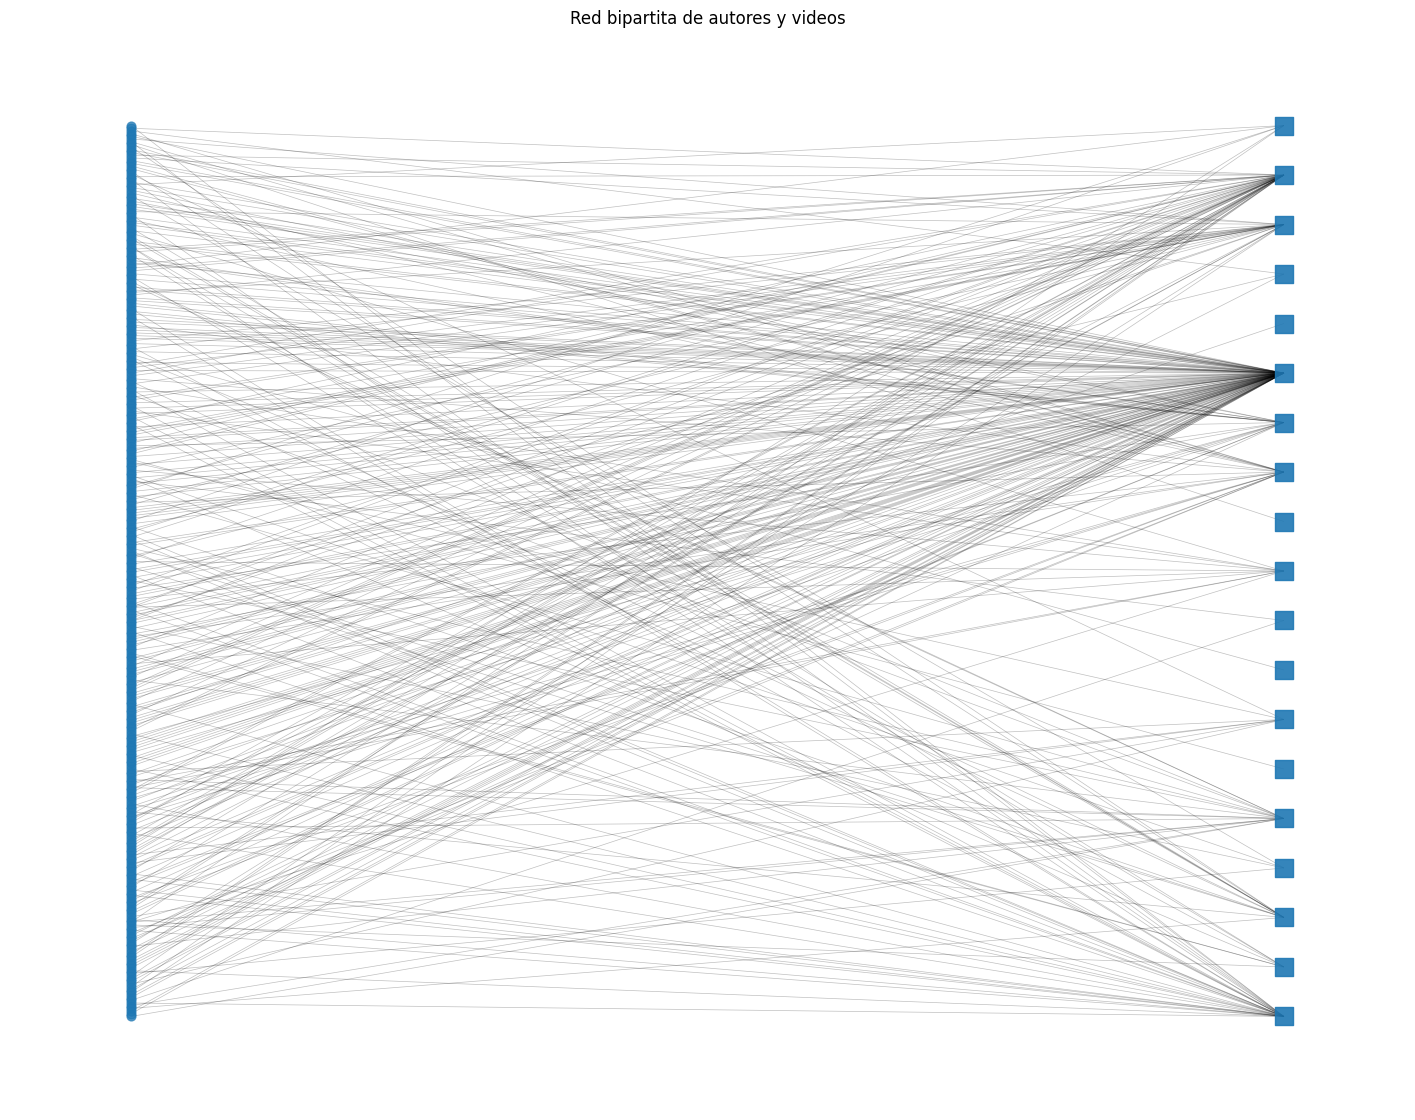

In [29]:
autores = [nodo for nodo, datos in G.nodes(data=True) if datos["tipo"] == "autor"]
videos_grafo = [nodo for nodo, datos in G.nodes(data=True) if datos["tipo"] == "video"]
pos_bipartita = nx.bipartite_layout(G, autores, align="vertical")
plt.figure(figsize=(18, 14))

nx.draw_networkx_nodes(G, pos_bipartita, nodelist=autores, node_size=40, node_shape="o", alpha=0.7)
nx.draw_networkx_nodes(G, pos_bipartita, nodelist=videos_grafo, node_size=150, node_shape="s", alpha=0.9)
nx.draw_networkx_edges(G, pos_bipartita, width=0.5, alpha=0.25)
plt.title("Red bipartita de autores y videos")
plt.axis("off")
plt.show()

In [31]:
print(nodos_autores.shape)
print(nodos_videos.shape)

(332, 7)
(19, 10)


Podemos observar del lado izquierdo los autores y del derecho los videos. Podemos ver que muchos autores comentan en pocos videos.  
Podemos observar que la gran mayoría de los autores tienen una gran cantidad de comentarios.  
Algunos videos son muy poco comentados, mientras que otros tienen muchos comentarios.

## 4.5) ¿Qué significa una arista?

En la red bipartita autor-video, una arista indica que un autor publicó al menos un comentario en un video. El peso de la arista indica el número de comentarios observados del autor en dicho video.  
Por lo tanto, una arista representa cuantas veces ha participado en el contenido.